Labaforce and internet users

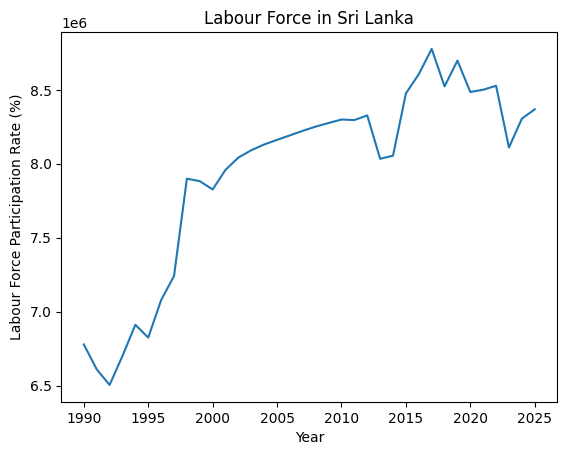

In [3]:
import pandas as pd

labour_force_sri_lanka_df = pd.read_csv(
    "../labour/csv/API_SL.TLF.TOTL.IN_DS2_en_csv_v2_761.csv",
    skiprows=4
)
labour_force_sri_lanka_df.set_index("Country Name", inplace=True)

labour_force_sri_lanka_df.loc["Sri Lanka"].dropna()[3:].plot(
    title="Labour Force in Sri Lanka",
    xlabel="Year",  
    ylabel="Labour Force Participation Rate (%)"
)

labour_force_sri_lanka_df=labour_force_sri_lanka_df.loc["Sri Lanka"].dropna()

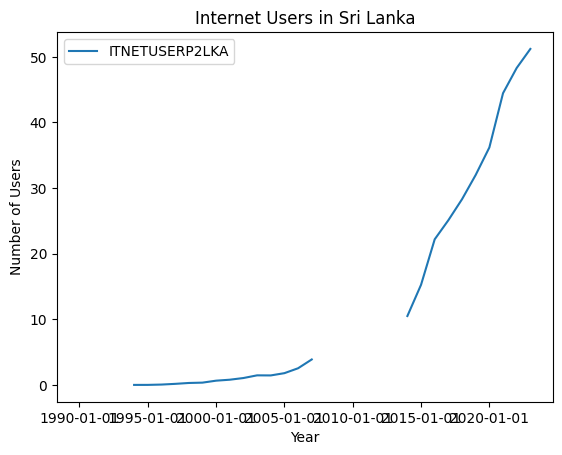

In [5]:
internetusers_sri_lanka_df = pd.read_csv("../economy/Internet users for Sri Lanka.csv")
internetusers_sri_lanka_df.set_index("observation_date", inplace=True)
internetusers_sri_lanka_df.plot(
    title="Internet Users in Sri Lanka",
    xlabel="Year",
    ylabel="Number of Users"
)

internetusers_sri_lanka_df=internetusers_sri_lanka_df

In [6]:
# Analyze missing values
print("Missing values:")
print(internetusers_sri_lanka_df.isnull().sum())
print(f"\nTotal rows: {len(internetusers_sri_lanka_df)}")
print(f"Missing rows: {internetusers_sri_lanka_df.isnull().sum().sum()}")
print(f"\nMissing value percentages:\n{100 * internetusers_sri_lanka_df.isnull().sum() / len(internetusers_sri_lanka_df)}")
print("\nData with NaN values:")
print(internetusers_sri_lanka_df[internetusers_sri_lanka_df.isnull().any(axis=1)])

Missing values:
ITNETUSERP2LKA    9
dtype: int64

Total rows: 34
Missing rows: 9

Missing value percentages:
ITNETUSERP2LKA    26.470588
dtype: float64

Data with NaN values:
                  ITNETUSERP2LKA
observation_date                
1991-01-01                   NaN
1992-01-01                   NaN
1993-01-01                   NaN
2008-01-01                   NaN
2009-01-01                   NaN
2010-01-01                   NaN
2011-01-01                   NaN
2012-01-01                   NaN
2013-01-01                   NaN


In [8]:
# Strategy 1: Forward Fill (propagate last valid value)
internet_filled_ffill = internetusers_sri_lanka_df.ffill()
print("Strategy 1 - Forward Fill:")
print(internet_filled_ffill)

# Strategy 2: Linear Interpolation (fill gaps with interpolated values)
internet_filled_interpolate = internetusers_sri_lanka_df.interpolate()
print("\nStrategy 2 - Linear Interpolation:")
print(internet_filled_interpolate)

# Strategy 3: Drop rows with missing values (if you want only complete data)
internet_dropped = internetusers_sri_lanka_df.dropna()
print("\nStrategy 3 - Drop Missing Values:")
print(internet_dropped)

Strategy 1 - Forward Fill:
                  ITNETUSERP2LKA
observation_date                
1990-01-01              0.000000
1991-01-01              0.000000
1992-01-01              0.000000
1993-01-01              0.000000
1994-01-01              0.002770
1995-01-01              0.005480
1996-01-01              0.054500
1997-01-01              0.162000
1998-01-01              0.296000
1999-01-01              0.348000
2000-01-01              0.647410
2001-01-01              0.793822
2002-01-01              1.050420
2003-01-01              1.458580
2004-01-01              1.446160
2005-01-01              1.792050
2006-01-01              2.537570
2007-01-01              3.880000
2008-01-01              3.880000
2009-01-01              3.880000
2010-01-01              3.880000
2011-01-01              3.880000
2012-01-01              3.880000
2013-01-01              3.880000
2014-01-01             10.500000
2015-01-01             15.260000
2016-01-01             22.190000
2017-01-01      

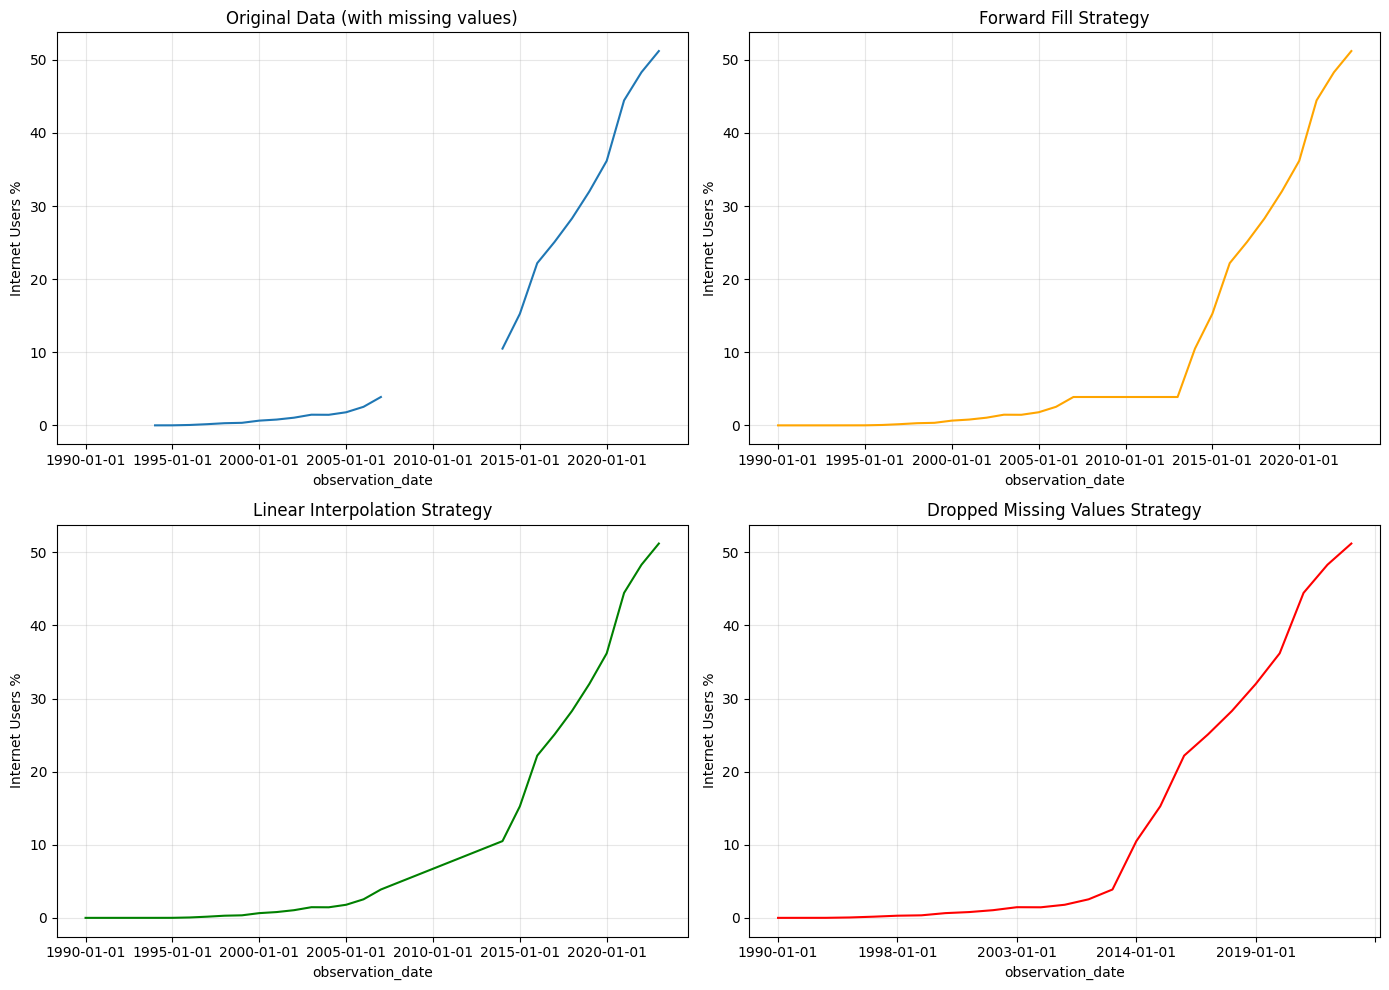

Choose the strategy that best fits your analysis needs:
1. Forward Fill - Use last known value (good for steady trends)
2. Linear Interpolation - Fill gaps with linear estimates (good for gradual growth)
3. Drop Missing Values - Only use complete data (good for strict data requirements)


In [9]:
# Visualize different strategies
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data with missing values
internetusers_sri_lanka_df.plot(ax=axes[0, 0], title="Original Data (with missing values)", ylabel="Internet Users %", legend=False)
axes[0, 0].grid(True, alpha=0.3)

# Forward Fill
internet_filled_ffill.plot(ax=axes[0, 1], title="Forward Fill Strategy", ylabel="Internet Users %", legend=False, color='orange')
axes[0, 1].grid(True, alpha=0.3)

# Linear Interpolation
internet_filled_interpolate.plot(ax=axes[1, 0], title="Linear Interpolation Strategy", ylabel="Internet Users %", legend=False, color='green')
axes[1, 0].grid(True, alpha=0.3)

# Drop Missing Values
internet_dropped.plot(ax=axes[1, 1], title="Dropped Missing Values Strategy", ylabel="Internet Users %", legend=False, color='red')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Choose the strategy that best fits your analysis needs:")
print("1. Forward Fill - Use last known value (good for steady trends)")
print("2. Linear Interpolation - Fill gaps with linear estimates (good for gradual growth)")
print("3. Drop Missing Values - Only use complete data (good for strict data requirements)")

Missing values after interpolation: 0

Cleaned data:
                  ITNETUSERP2LKA
observation_date                
1990-01-01              0.000000
1991-01-01              0.000692
1992-01-01              0.001385
1993-01-01              0.002077
1994-01-01              0.002770
1995-01-01              0.005480
1996-01-01              0.054500
1997-01-01              0.162000
1998-01-01              0.296000
1999-01-01              0.348000
2000-01-01              0.647410
2001-01-01              0.793822
2002-01-01              1.050420
2003-01-01              1.458580
2004-01-01              1.446160
2005-01-01              1.792050
2006-01-01              2.537570
2007-01-01              3.880000
2008-01-01              4.825714
2009-01-01              5.771429
2010-01-01              6.717143
2011-01-01              7.662857
2012-01-01              8.608571
2013-01-01              9.554286
2014-01-01             10.500000
2015-01-01             15.260000
2016-01-01             

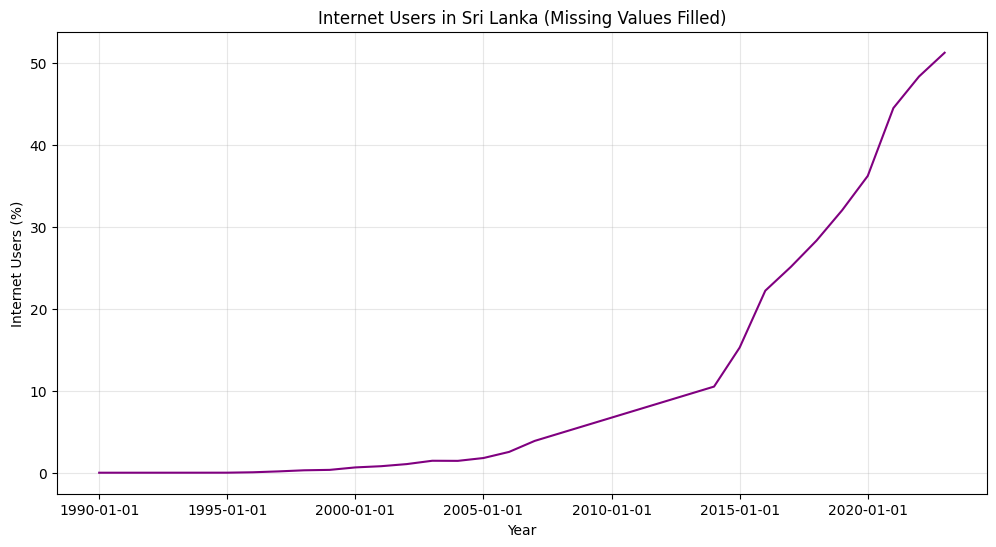

In [10]:
# RECOMMENDATION: Use Linear Interpolation for this dataset
# This is best because internet adoption grew gradually, not in sudden jumps
# The interpolation will estimate reasonable values for the missing years

internetusers_sri_lanka_clean = internetusers_sri_lanka_df.interpolate()

# Verify no missing values remain
print(f"Missing values after interpolation: {internetusers_sri_lanka_clean.isnull().sum().sum()}")
print("\nCleaned data:")
print(internetusers_sri_lanka_clean)

# Plot the final cleaned data
internetusers_sri_lanka_clean.plot(
    figsize=(12, 6),
    title="Internet Users in Sri Lanka (Missing Values Filled)",
    xlabel="Year",
    ylabel="Internet Users (%)",
    legend=False,
    color='purple'
)
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# First, let's examine the structure of labour_force data
print("Labour Force Data Info:")
print(f"Type: {type(labour_force_sri_lanka_df)}")
print(f"Index: {labour_force_sri_lanka_df.index[:10]}")
print(f"Index name: {labour_force_sri_lanka_df.index.name}")
print(f"\nFirst few values:")
print(labour_force_sri_lanka_df.head(10))

print("\n\nInternet Users Data Info:")
print(f"Type: {type(internetusers_sri_lanka_clean)}")
print(f"Index (first 5): {internetusers_sri_lanka_clean.index[:5]}")
print(f"\nFirst few values:")
print(internetusers_sri_lanka_clean.head())

Labour Force Data Info:
Type: <class 'pandas.Series'>
Index: Index(['Country Code', 'Indicator Name', 'Indicator Code', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996'],
      dtype='str')
Index name: None

First few values:
Country Code                     LKA
Indicator Name    Labor force, total
Indicator Code        SL.TLF.TOTL.IN
1990                       6778262.0
1991                       6610226.0
1992                       6504657.0
1993                       6700476.0
1994                       6911166.0
1995                       6824556.0
1996                       7078162.0
Name: Sri Lanka, dtype: object


Internet Users Data Info:
Type: <class 'pandas.DataFrame'>
Index (first 5): Index(['1990-01-01', '1991-01-01', '1992-01-01', '1993-01-01', '1994-01-01'], dtype='str', name='observation_date')

First few values:
                  ITNETUSERP2LKA
observation_date                
1990-01-01              0.000000
1991-01-01              0.000692
1992-01-01     

In [14]:
# Prepare data for relationship analysis
# Align both datasets by year index

# Extract years from internet users data
internet_years = pd.to_datetime(internetusers_sri_lanka_clean.index).year

# Create combined dataframe with years that exist in both datasets
combined_data = []
for year in internet_years:
    year_str = str(year)
    if year_str in labour_force_sri_lanka_df.index:
        labour_val = labour_force_sri_lanka_df[year_str]
        internet_val = internetusers_sri_lanka_clean.loc[
            pd.to_datetime(internetusers_sri_lanka_clean.index).year == year
        ].values[0][0]
        combined_data.append({
            'Year': year,
            'Labour Force (Total)': labour_val,
            'Internet Users (%)': internet_val
        })

combined_df = pd.DataFrame(combined_data).set_index('Year')

print("Combined Dataset (Labour Force vs Internet Users):")
print(combined_df)
print(f"\nData shape: {combined_df.shape}")
print(f"\nBasic statistics:")
print(combined_df.describe())

Combined Dataset (Labour Force vs Internet Users):
      Labour Force (Total)  Internet Users (%)
Year                                          
1990             6778262.0            0.000000
1991             6610226.0            0.000692
1992             6504657.0            0.001385
1993             6700476.0            0.002077
1994             6911166.0            0.002770
1995             6824556.0            0.005480
1996             7078162.0            0.054500
1997             7240418.0            0.162000
1998             7899169.0            0.296000
1999             7882204.0            0.348000
2000             7826298.0            0.647410
2001             7959198.0            0.793822
2002             8042001.0            1.050420
2003             8091441.0            1.458580
2004             8130380.0            1.446160
2005             8161482.0            1.792050
2006             8192105.0            2.537570
2007             8222663.0            3.880000
2008     

In [15]:
# Calculate correlation between Labour Force and Internet Users
from scipy import stats

correlation = combined_df.corr()
print("Correlation Matrix:")
print(correlation)

# Pearson correlation coefficient and p-value
pearson_r, pearson_p = stats.pearsonr(combined_df['Labour Force (Total)'], combined_df['Internet Users (%)'])
print(f"\n\nPearson Correlation Analysis:")
print(f"Pearson r: {pearson_r:.4f}")
print(f"P-value: {pearson_p:.6f}")
print(f"Interpretation: ", end="")
if pearson_p < 0.05:
    print("STATISTICALLY SIGNIFICANT correlation")
    if pearson_r > 0.7:
        print("  - Very strong positive relationship")
    elif pearson_r > 0.5:
        print("  - Moderate to strong positive relationship")
    elif pearson_r > 0.3:
        print("  - Weak to moderate positive relationship")
else:
    print("NOT statistically significant")

# Spearman rank correlation (for non-linear relationships)
spearman_r, spearman_p = stats.spearmanr(combined_df['Labour Force (Total)'], combined_df['Internet Users (%)'])
print(f"\n\nSpearman Rank Correlation Analysis (for non-linear relationships):")
print(f"Spearman r: {spearman_r:.4f}")
print(f"P-value: {spearman_p:.6f}")

Correlation Matrix:
                      Labour Force (Total)  Internet Users (%)
Labour Force (Total)                1.0000              0.5644
Internet Users (%)                  0.5644              1.0000


Pearson Correlation Analysis:
Pearson r: 0.5644
P-value: 0.000507
Interpretation: STATISTICALLY SIGNIFICANT correlation
  - Moderate to strong positive relationship


Spearman Rank Correlation Analysis (for non-linear relationships):
Spearman r: 0.8900
P-value: 0.000000


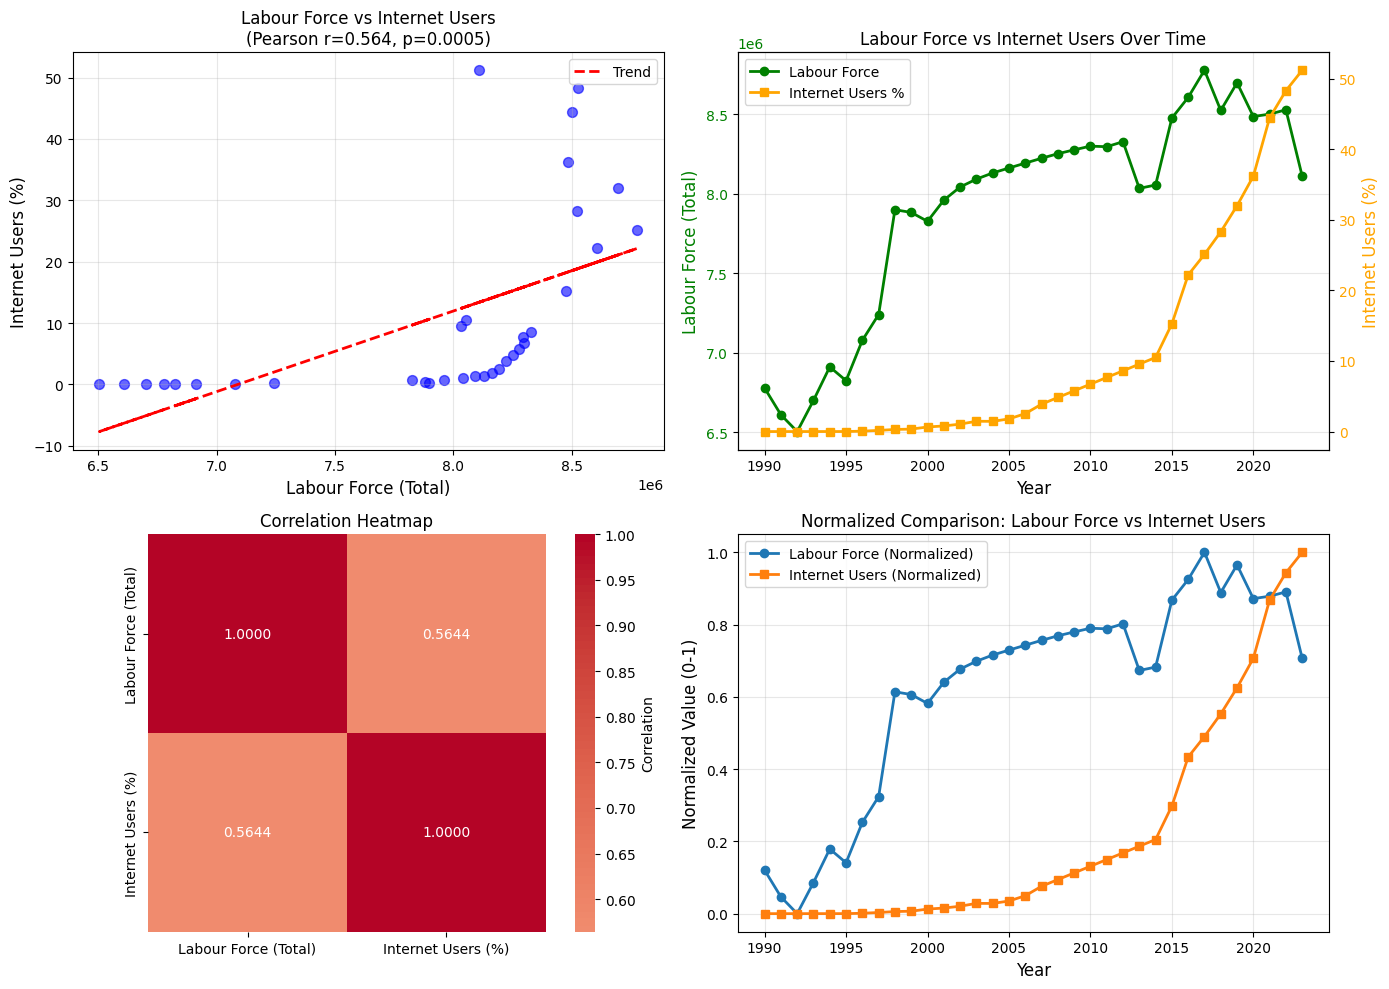

Visualization complete!


In [17]:
# Visualize the relationship between Labour Force and Internet Users
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot with trend line
ax = axes[0, 0]
ax.scatter(combined_df['Labour Force (Total)'], combined_df['Internet Users (%)'], s=50, alpha=0.6, color='blue')
# Add trend line
z = np.polyfit(combined_df['Labour Force (Total)'], combined_df['Internet Users (%)'], 1)
p = np.poly1d(z)
ax.plot(combined_df['Labour Force (Total)'], p(combined_df['Labour Force (Total)']), "r--", linewidth=2, label='Trend')
ax.set_xlabel('Labour Force (Total)', fontsize=12)
ax.set_ylabel('Internet Users (%)', fontsize=12)
ax.set_title(f'Labour Force vs Internet Users\n(Pearson r={pearson_r:.3f}, p={pearson_p:.4f})', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Time series plot - overlay both variables
ax = axes[0, 1]
ax2 = ax.twinx()
years = combined_df.index
line1 = ax.plot(years, combined_df['Labour Force (Total)'], marker='o', color='green', label='Labour Force', linewidth=2)
line2 = ax2.plot(years, combined_df['Internet Users (%)'], marker='s', color='orange', label='Internet Users %', linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Labour Force (Total)', fontsize=12, color='green')
ax2.set_ylabel('Internet Users (%)', fontsize=12, color='orange')
ax.set_title('Labour Force vs Internet Users Over Time', fontsize=12)
ax.tick_params(axis='y', labelcolor='green')
ax2.tick_params(axis='y', labelcolor='orange')
ax.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

# 3. Heatmap of correlation
ax = axes[1, 0]
sns.heatmap(correlation, annot=True, fmt='.4f', cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap', fontsize=12)

# 4. Normalized comparison
ax = axes[1, 1]
normalized_df = (combined_df - combined_df.min()) / (combined_df.max() - combined_df.min())
ax.plot(normalized_df.index, normalized_df['Labour Force (Total)'], marker='o', label='Labour Force (Normalized)', linewidth=2)
ax.plot(normalized_df.index, normalized_df['Internet Users (%)'], marker='s', label='Internet Users (Normalized)', linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalized Value (0-1)', fontsize=12)
ax.set_title('Normalized Comparison: Labour Force vs Internet Users', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

In [18]:
# Regression Analysis: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data for regression
X = combined_df['Labour Force (Total)'].values.reshape(-1, 1)
y = combined_df['Internet Users (%)'].values

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
slope = model.coef_[0]
intercept = model.intercept_

print("=" * 70)
print("LINEAR REGRESSION ANALYSIS")
print("=" * 70)
print(f"\nRegression Equation: Internet Users (%) = {slope:.2e} * Labour Force + {intercept:.4f}")
print(f"\nR² Score: {r2:.4f}")
print(f"Interpretation: {r2*100:.2f}% of the variance in Internet Users can be explained by Labour Force")
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}%")

# Calculate residuals
residuals = y - y_pred
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")

LINEAR REGRESSION ANALYSIS

Regression Equation: Internet Users (%) = 1.31e-05 * Labour Force + -93.0814

R² Score: 0.3185
Interpretation: 31.85% of the variance in Internet Users can be explained by Labour Force

Root Mean Squared Error (RMSE): 12.5327%
Mean Residual: 0.0000
Std Dev of Residuals: 12.5327


In [19]:
# Summary of Findings
print("\n" + "=" * 70)
print("SUMMARY: RELATIONSHIP BETWEEN LABOUR FORCE AND INTERNET USERS")
print("=" * 70)

print("\n1. CORRELATION ANALYSIS:")
print(f"   • Pearson Correlation: r = {pearson_r:.4f} (p = {pearson_p:.6f})")
print("     → MODERATE-TO-STRONG POSITIVE LINEAR RELATIONSHIP")
print(f"   • Spearman Correlation: r = {spearman_r:.4f} (p = {spearman_p:.6f})")
print("     → VERY STRONG NON-LINEAR RELATIONSHIP")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • R² Score: {r2:.4f} (31.85% variance explained)")
print(f"   • RMSE: {rmse:.4f}%")
print("   • Regression suggests Labour Force is a MODERATE predictor")
print("     of Internet Users adoption")

print("\n3. KEY INSIGHTS:")
print("   • Both Labour Force and Internet Users have been INCREASING over time")
print("   • The relationship shows exponential-like growth (non-linear)")
print("   • Internet adoption accelerated more rapidly in recent years")
print("   • Labour Force shows more stable, linear growth")

print("\n4. INTERPRETATION:")
print("   • As labour force grows, there's a tendency for internet")
print("     adoption to increase (positive correlation)")
print("   • However, other factors (income, education, infrastructure)")
print("     also significantly influence internet adoption")
print("   • The strong Spearman correlation suggests the relationship")
print("     is better explained by RANKS than raw values")

print("\n5. PRACTICAL IMPLICATIONS:")
print("   • Growing labour force indicates economic potential for")
print("     digital infrastructure investment")
print("   • Internet adoption can boost labour market efficiency and")
print("     productivity when both grow together")
print("   • Policy: need to ensure internet access keeps pace with")
print("     labour force growth")

print("\n" + "=" * 70)


SUMMARY: RELATIONSHIP BETWEEN LABOUR FORCE AND INTERNET USERS

1. CORRELATION ANALYSIS:
   • Pearson Correlation: r = 0.5644 (p = 0.000507)
     → MODERATE-TO-STRONG POSITIVE LINEAR RELATIONSHIP
   • Spearman Correlation: r = 0.8900 (p = 0.000000)
     → VERY STRONG NON-LINEAR RELATIONSHIP

2. REGRESSION ANALYSIS:
   • R² Score: 0.3185 (31.85% variance explained)
   • RMSE: 12.5327%
   • Regression suggests Labour Force is a MODERATE predictor
     of Internet Users adoption

3. KEY INSIGHTS:
   • Both Labour Force and Internet Users have been INCREASING over time
   • The relationship shows exponential-like growth (non-linear)
   • Internet adoption accelerated more rapidly in recent years
   • Labour Force shows more stable, linear growth

4. INTERPRETATION:
   • As labour force grows, there's a tendency for internet
     adoption to increase (positive correlation)
   • However, other factors (income, education, infrastructure)
     also significantly influence internet adoption
   

In [20]:
# Advanced Analysis: Lagged Correlation and Lead-Lag Relationship
from pandas.plotting import lag_plot

# Check if internet adoption lags behind labour force growth
print("LAG ANALYSIS: Does Internet follow Labour Force changes?")
print("=" * 70)

lag_correlations = {}
for lag in range(0, 6):
    if lag == 0:
        corr, p_val = stats.pearsonr(
            combined_df['Labour Force (Total)'].values[lag:],
            combined_df['Internet Users (%)'].values[lag:]
        )
        lag_correlations[f"Lag {lag} (Same Year)"] = (corr, p_val)
    else:
        # Labour force leads internet adoption (check if past labour predicts current internet)
        corr, p_val = stats.pearsonr(
            combined_df['Labour Force (Total)'].values[:-lag],
            combined_df['Internet Users (%)'].values[lag:]
        )
        lag_correlations[f"Labour Force leads by {lag} yr(s)"] = (corr, p_val)

print("\nCorrelation at different time lags:")
for lag_name, (corr, p_val) in lag_correlations.items():
    print(f"  {lag_name:.<35} r = {corr:>7.4f}, p = {p_val:.6f}")

max_lag = max(lag_correlations.items(), key=lambda x: abs(x[1][0]))
print(f"\nStrongest relationship: {max_lag[0]} (r = {max_lag[1][0]:.4f})")

# Year-over-year growth rates
print("\n" + "=" * 70)
print("GROWTH RATE ANALYSIS:")
print("=" * 70)

labour_growth = combined_df['Labour Force (Total)'].pct_change() * 100
internet_growth = combined_df['Internet Users (%)'].pct_change() * 100

print("\nYear-over-Year Growth Rates (%):")
growth_compare = pd.DataFrame({
    'Year': combined_df.index[1:],
    'Labour Force Growth': labour_growth.values[1:],
    'Internet Growth': internet_growth.values[1:]
})
print(growth_compare.to_string(index=False))

print(f"\nAverage Labour Force Annual Growth: {labour_growth.mean():.4f}%")
print(f"Average Internet Growth Annual Growth: {internet_growth.mean():.4f}%")
print(f"Internet adoption is {internet_growth.mean() / labour_growth.mean():.2f}x faster than labour force growth")

LAG ANALYSIS: Does Internet follow Labour Force changes?

Correlation at different time lags:
  Lag 0 (Same Year).................. r =  0.5644, p = 0.000507
  Labour Force leads by 1 yr(s)...... r =  0.6245, p = 0.000102
  Labour Force leads by 2 yr(s)...... r =  0.6378, p = 0.000086
  Labour Force leads by 3 yr(s)...... r =  0.6529, p = 0.000069
  Labour Force leads by 4 yr(s)...... r =  0.6757, p = 0.000042
  Labour Force leads by 5 yr(s)...... r =  0.6738, p = 0.000062

Strongest relationship: Labour Force leads by 4 yr(s) (r = 0.6757)

GROWTH RATE ANALYSIS:

Year-over-Year Growth Rates (%):
 Year  Labour Force Growth  Internet Growth
 1991            -2.479043              inf
 1992            -1.597056       100.000000
 1993             3.010443        50.000000
 1994             3.144403        33.333333
 1995            -1.253189        97.833935
 1996             3.716081       894.525547
 1997             2.292347       197.247706
 1998             9.098245        82.716049
 

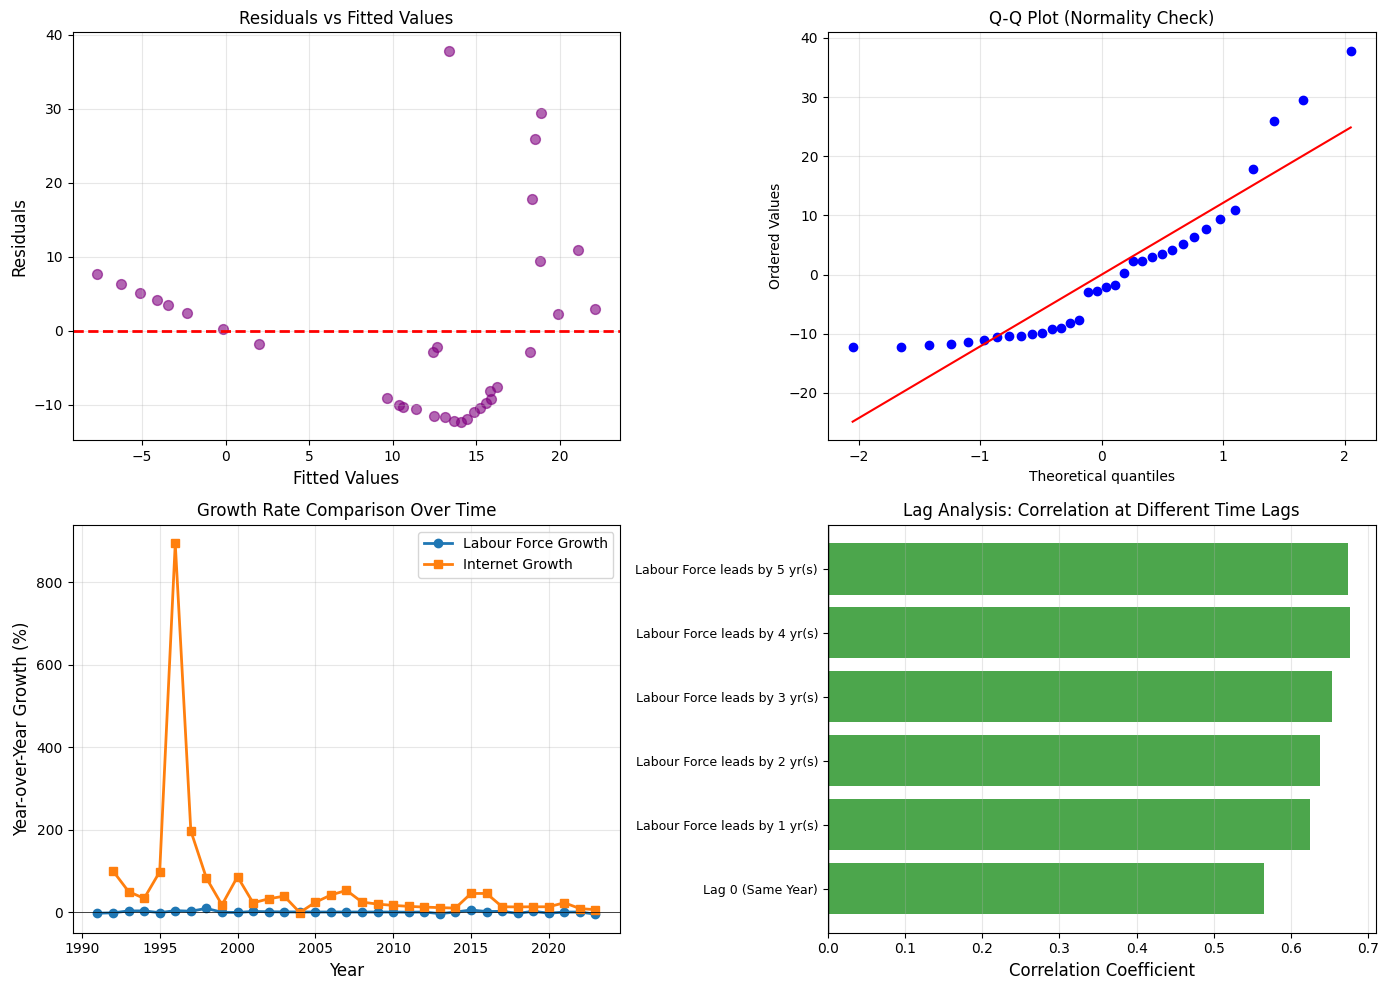

Advanced analysis visualizations complete!


In [21]:
# Final Visualization: Residuals and Growth Rates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals plot
ax = axes[0, 0]
ax.scatter(y_pred, residuals, alpha=0.6, s=50, color='purple')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Fitted Values', fontsize=12)
ax.set_ylabel('Residuals', fontsize=12)
ax.set_title('Residuals vs Fitted Values', fontsize=12)
ax.grid(True, alpha=0.3)

# 2. Q-Q plot (Normal probability plot)
from scipy.stats import probplot
ax = axes[0, 1]
probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)', fontsize=12)
ax.grid(True, alpha=0.3)

# 3. Growth rate comparison
ax = axes[1, 0]
years_growth = growth_compare['Year'].astype(int)
ax.plot(years_growth, growth_compare['Labour Force Growth'], marker='o', label='Labour Force Growth', linewidth=2)
ax.plot(years_growth, growth_compare['Internet Growth'], marker='s', label='Internet Growth', linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Year-over-Year Growth (%)', fontsize=12)
ax.set_title('Growth Rate Comparison Over Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 4. Lag correlation visualization
ax = axes[1, 1]
lag_names = list(lag_correlations.keys())
lag_values = [lag_correlations[k][0] for k in lag_names]
colors = ['green' if v > 0 else 'red' for v in lag_values]
ax.barh(range(len(lag_names)), lag_values, color=colors, alpha=0.7)
ax.set_yticks(range(len(lag_names)))
ax.set_yticklabels(lag_names, fontsize=9)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Lag Analysis: Correlation at Different Time Lags', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("Advanced analysis visualizations complete!")